# Cell Preprocessing Investigation

**Purpose:** Trace exactly how a newspaper photo becomes the 28×28 tensor the CNN sees, and answer a stack of questions that keep coming up during OCR debugging:

1. When `detect_grid` runs CLAHE + adaptive threshold, does that processed image survive into the cell OCR path, or do the cells come from the unmodified original?
2. What does the inside of `CNNRecognizer._preprocess` actually do, step by step?
3. Is the hard-coded `h//10` inner-margin crop too aggressive? Does it clip digit strokes, or does it leave grid-line artefacts? Does the right margin depend on the cell?
4. Does `/api/debug` (the interactive pipeline visualiser) preprocess cells the same way production does?
5. Do training samples and inference cells arrive at the CNN through the same transformation chain, or do they diverge?

This notebook is a diagnostic tool, not a benchmark. It runs against a single sample image by default; change `IMAGE_NAME` in the setup cell to pick a different one.


## 0. Setup

Imports + pick a sample. Defaults to `_22_7288515.jpeg`, which is one of the clean-print GT images (100% filled-cell accuracy on both v2 and v3) so the visualisations aren't dominated by detection failures.


In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "app").is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # CNNRecognizer and datasets use CWD-relative paths

from app.core.extraction import (
    detect_grid,
    extract_cells,
    perspective_transform,
    _preprocess as detection_preprocess,
)
from app.ml.recognizer import CNNRecognizer
from app.ml.dataset import (
    PrintedDigitDataset,
    Chars74KFontDataset,
    EmptyCellDataset,
    AugmentedDataset,
)
from torchvision import datasets as tv_datasets
from torchvision import transforms as tv_transforms

IMAGE_NAME = "_22_7288515.jpeg"
IMAGE_PATH = PROJECT_ROOT / "Examples" / "Ground Example" / IMAGE_NAME

assert IMAGE_PATH.exists(), (
    f"Sample image missing at {IMAGE_PATH}. "
    "Set IMAGE_NAME above to a filename in Examples/Ground Example/."
)

bgr = cv2.imread(str(IMAGE_PATH))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
print(f"Loaded {IMAGE_NAME}: {bgr.shape[1]}×{bgr.shape[0]} BGR")


Loaded _22_7288515.jpeg: 600×600 BGR


## 1. The detection pipeline

`detect_grid` runs CLAHE + Gaussian blur + adaptive threshold on a grayscale copy of the input, then finds a convex-quad contour in that binary image. The binary/CLAHE image is **only used for contour finding** — once `detect_grid` returns the 4 corners, the downstream `perspective_transform` warps the **original BGR image** through those corners. CLAHE never touches the cell inputs.

To make this visible, we'll render the full Step-1 preprocessing chain next to the contour overlay and the warped output, and verify by inspection that the warped image looks like the original (contrast/tone preserved) rather than the CLAHE-enhanced threshold.


detect_grid confidence = 0.84


/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_85171/806454340.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_85171/806454340.py:42: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


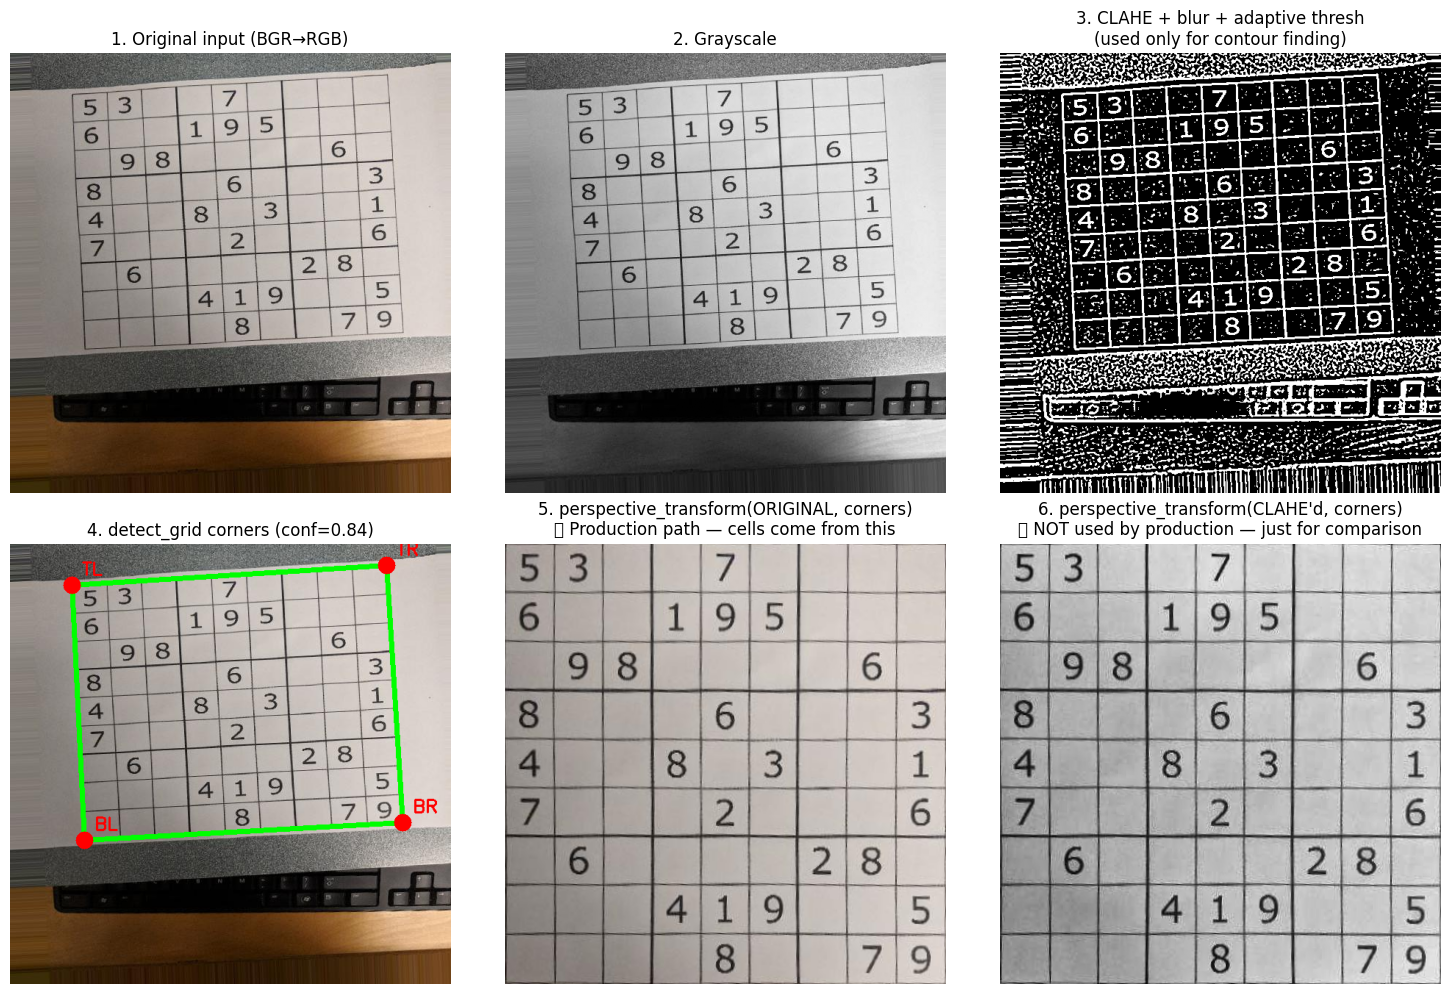

In [2]:
# Step 1 of detect_grid's fallback chain: default _preprocess
thresh = detection_preprocess(gray)  # CLAHE(2.0) + blur(5x5) + adaptiveThreshold

# Also run the aggressive Step 3 variant (CLAHE clip=6, C=7) for comparison
thresh_aggressive = detection_preprocess(gray, clahe_clip=6.0, thresh_c=7)

# Run detect_grid to get the production 4 corners
corners, confidence = detect_grid(bgr)
assert corners is not None, "detect_grid failed on this sample"
print(f"detect_grid confidence = {confidence:.2f}")

# Overlay corners on the original
overlay = rgb.copy()
pts = corners.astype(np.int32)
cv2.polylines(overlay, [pts], True, (0, 255, 0), 5)
labels = ["TL", "TR", "BR", "BL"]
for (x, y), lab in zip(pts, labels):
    cv2.circle(overlay, (x, y), 12, (255, 0, 0), -1)
    cv2.putText(overlay, lab, (x + 14, y - 14), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# Warp (production: original BGR image, not the CLAHE'd one)
warped_original = perspective_transform(bgr, corners.reshape(4, 1, 2).astype(np.float32))
warped_rgb = cv2.cvtColor(warped_original, cv2.COLOR_BGR2RGB)

# For comparison only: what would the warped look like if we'd warped the CLAHE'd image?
clahe_img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
warped_clahe = perspective_transform(
    cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR),
    corners.reshape(4, 1, 2).astype(np.float32),
)
warped_clahe_rgb = cv2.cvtColor(warped_clahe, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(rgb); axes[0, 0].set_title("1. Original input (BGR→RGB)")
axes[0, 1].imshow(gray, cmap="gray"); axes[0, 1].set_title("2. Grayscale")
axes[0, 2].imshow(thresh, cmap="gray"); axes[0, 2].set_title("3. CLAHE + blur + adaptive thresh\n(used only for contour finding)")
axes[1, 0].imshow(overlay); axes[1, 0].set_title(f"4. detect_grid corners (conf={confidence:.2f})")
axes[1, 1].imshow(warped_rgb); axes[1, 1].set_title("5. perspective_transform(ORIGINAL, corners)\n✅ Production path — cells come from this")
axes[1, 2].imshow(warped_clahe_rgb); axes[1, 2].set_title("6. perspective_transform(CLAHE'd, corners)\n❌ NOT used by production — just for comparison")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Finding 1:** Panel 5 ("production path") and panel 6 ("CLAHE'd") look obviously different — panel 5 has the original tonal range (paper tone visible, soft anti-aliasing on digits), while panel 6 is harsh-contrast CLAHE output. Production cells come from panel 5. **CLAHE never touches the cell inputs seen by the CNN.**

Technical trace from `app/core/extraction.py`:
- `detect_grid(image)` → calls `_preprocess(gray)` → returns a binary `thresh` image → passes it to `_find_best_quad_structured(image, thresh, ...)`.
- Inside `_find_best_quad_structured`, the ranked quads are drawn from contours in `thresh`, but the **scoring helpers** (`score_grid_structure`, `score_cell_count`) take the **original** `image` and do their own warp for scoring purposes.
- After `detect_grid` returns a `(corners, confidence)` pair, `recognize_cells` calls `perspective_transform(image, contour)` with `image` = the original BGR — **not the preprocessed one.**


## 2. Cell extraction

`extract_cells` is dumb: integer-divides the warped grid into `height//9 × width//9` tiles and returns them in row-major order as BGR arrays. No padding, no resizing, no per-cell work. Whatever the warped grid looks like, that's what the cells inherit.


Got 81 cells, first cell shape = (48, 48, 3)


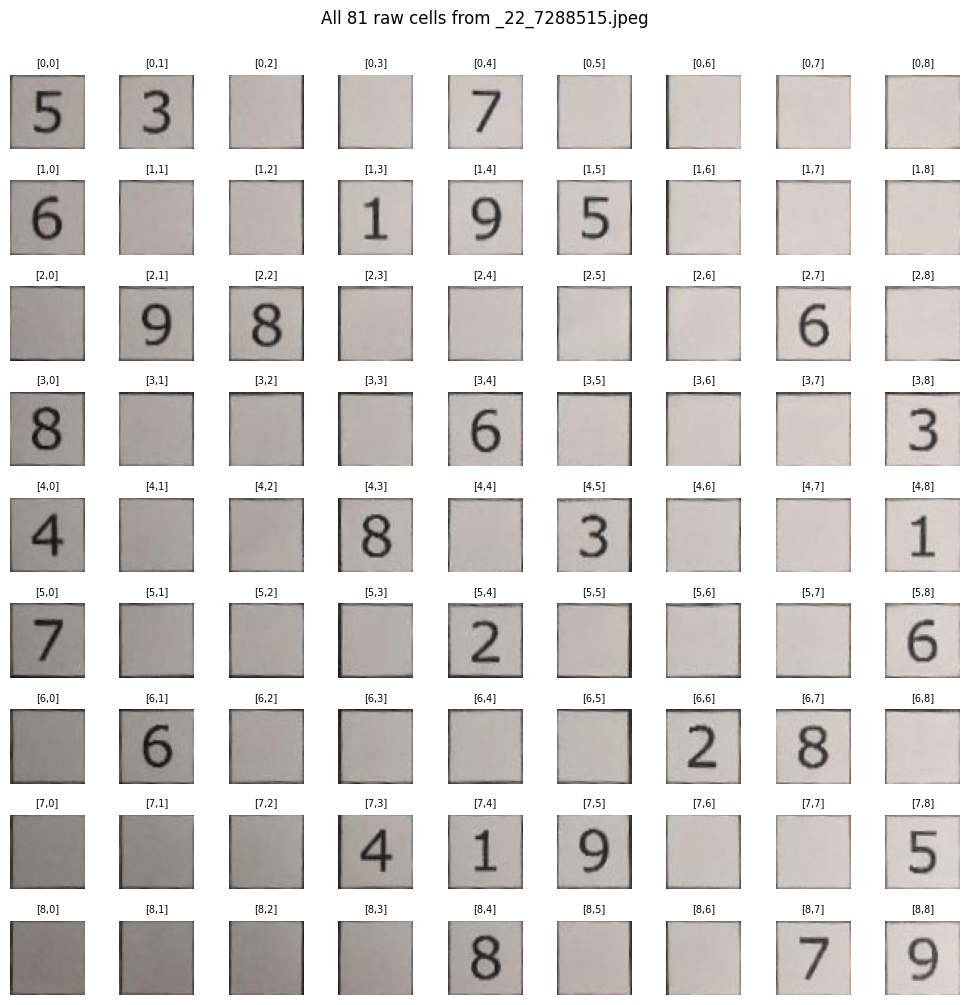

In [3]:
cells = extract_cells(warped_original)
print(f"Got {len(cells)} cells, first cell shape = {cells[0].shape}")

fig, axes = plt.subplots(9, 9, figsize=(10, 10))
for idx, ax in enumerate(axes.flat):
    cell_rgb = cv2.cvtColor(cells[idx], cv2.COLOR_BGR2RGB)
    ax.imshow(cell_rgb)
    ax.set_title(f"[{idx//9},{idx%9}]", fontsize=7)
    ax.axis("off")
plt.suptitle(f"All 81 raw cells from {IMAGE_NAME}", y=1.00)
plt.tight_layout()
plt.show()


## 3. `CNNRecognizer._preprocess` — the OCR preprocessing waterfall

This is where the cell becomes a 28×28 MNIST-polarity tensor. Each step of the chain is a single OpenCV call:

```python
def _preprocess(self, cell):
    # 1. grayscale (if needed)
    if len(cell.shape) == 3:
        cell = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    # 2. margin crop (hard-coded h//10, w//10)
    h, w = cell.shape
    my, mx = max(1, h // 10), max(1, w // 10)
    cell = cell[my:-my, mx:-mx]
    # 3. resize to 28×28
    cell = cv2.resize(cell, (28, 28), interpolation=cv2.INTER_AREA)
    # 4. invert to MNIST polarity (white digit on black)
    cell = 255 - cell
    # 5. min-max normalise to full [0,255]
    cell = cv2.normalize(cell, None, 0, 255, cv2.NORM_MINMAX)
    return cell  # uint8 (28, 28)
# predict() then divides by 255.0 to get the [0,1] float tensor
```

Let's run each step on a clear filled cell and an empty cell so the effect is visible.


Picked filled cell at index 0 ([0,0])
Picked empty  cell at index 2 ([0,2])


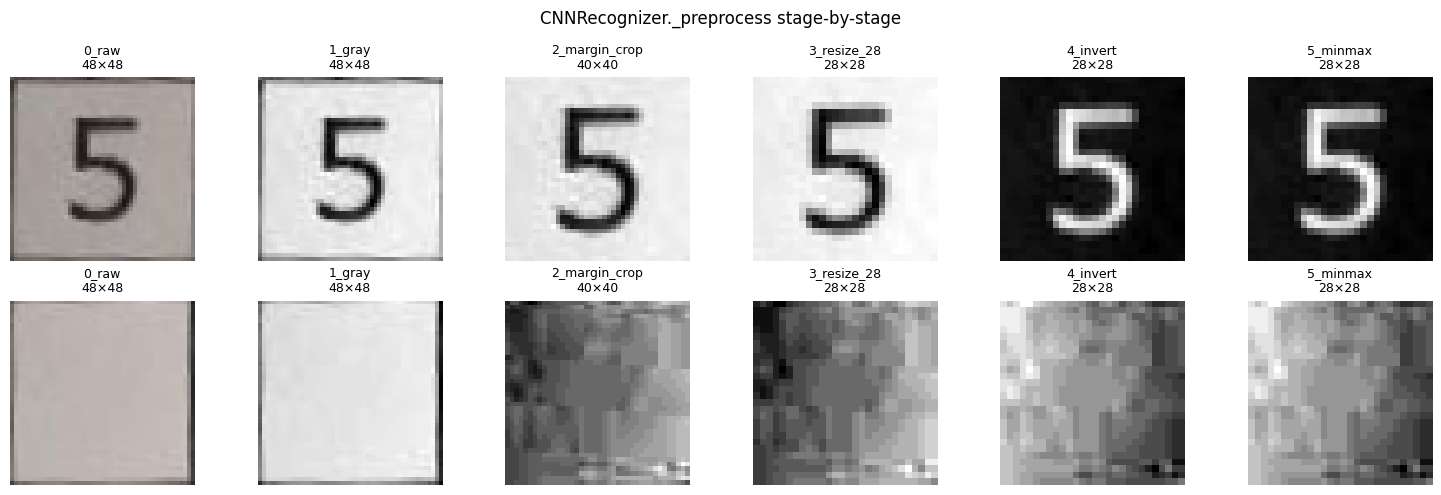

In [4]:
rec = CNNRecognizer()

def run_preprocess_stages(cell_bgr):
    stages = {}
    stages["0_raw"] = cell_bgr.copy()
    gray_cell = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2GRAY) if cell_bgr.ndim == 3 else cell_bgr
    stages["1_gray"] = gray_cell.copy()
    h, w = gray_cell.shape
    my, mx = max(1, h // 10), max(1, w // 10)
    stages["2_margin_crop"] = gray_cell[my:-my, mx:-mx].copy()
    stages["3_resize_28"] = cv2.resize(stages["2_margin_crop"], (28, 28), interpolation=cv2.INTER_AREA)
    stages["4_invert"] = 255 - stages["3_resize_28"]
    stages["5_minmax"] = cv2.normalize(stages["4_invert"], None, 0, 255, cv2.NORM_MINMAX)
    return stages

# Pick a clearly filled cell and an empty cell
# _22_ layout has a digit at roughly [0,0] and empties around it
filled_idx = None
empty_idx = None
for i, cell in enumerate(cells):
    g = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    inner = g[g.shape[0]//4 : -g.shape[0]//4, g.shape[1]//4 : -g.shape[1]//4]
    # A "filled" cell has high dark-pixel density in the center
    dark_ratio = float(np.sum(inner < 100) / inner.size)
    if filled_idx is None and dark_ratio > 0.15:
        filled_idx = i
    if empty_idx is None and dark_ratio < 0.02:
        empty_idx = i
    if filled_idx is not None and empty_idx is not None:
        break

print(f"Picked filled cell at index {filled_idx} ([{filled_idx//9},{filled_idx%9}])")
print(f"Picked empty  cell at index {empty_idx} ([{empty_idx//9},{empty_idx%9}])")

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for row, (label, idx) in enumerate([("filled", filled_idx), ("empty", empty_idx)]):
    stages = run_preprocess_stages(cells[idx])
    # Ground truth prediction via the recogniser
    digit, conf = rec.predict(cells[idx])
    for col, (stage_name, arr) in enumerate(stages.items()):
        ax = axes[row, col]
        cmap = "gray" if arr.ndim == 2 else None
        if arr.ndim == 3:
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
        ax.imshow(arr, cmap=cmap)
        size_str = f"{arr.shape[0]}×{arr.shape[1]}"
        ax.set_title(f"{stage_name}\n{size_str}", fontsize=9)
        ax.axis("off")
    axes[row, 0].set_ylabel(f"{label}\npred={digit} conf={conf:.2f}",
                             rotation=0, labelpad=40, fontsize=10)
plt.suptitle("CNNRecognizer._preprocess stage-by-stage")
plt.tight_layout()
plt.show()


## 4. Is the 10% margin too strict?

The hard-coded `h//10` / `w//10` crop is meant to shave off grid lines that leak into each cell from the warp. Two failure modes:

- **Too aggressive:** the inner crop clips a digit stroke on one side. That shows up as the 28×28 tensor having the digit truncated at a border, and the CNN can easily misread a clipped `1` as a `7` or a clipped `4` as a `9`.
- **Too loose:** leftover grid-line pixels invade the inner crop. The min-max normalize then stretches those lines to full brightness, creating artificial high-contrast edges the CNN hasn't trained on.

The right crop depends on how tightly the warp aligned to the outer grid line. Let's sweep margins on several cells and compare both the resulting 28×28 tensors and the CNN's predictions.


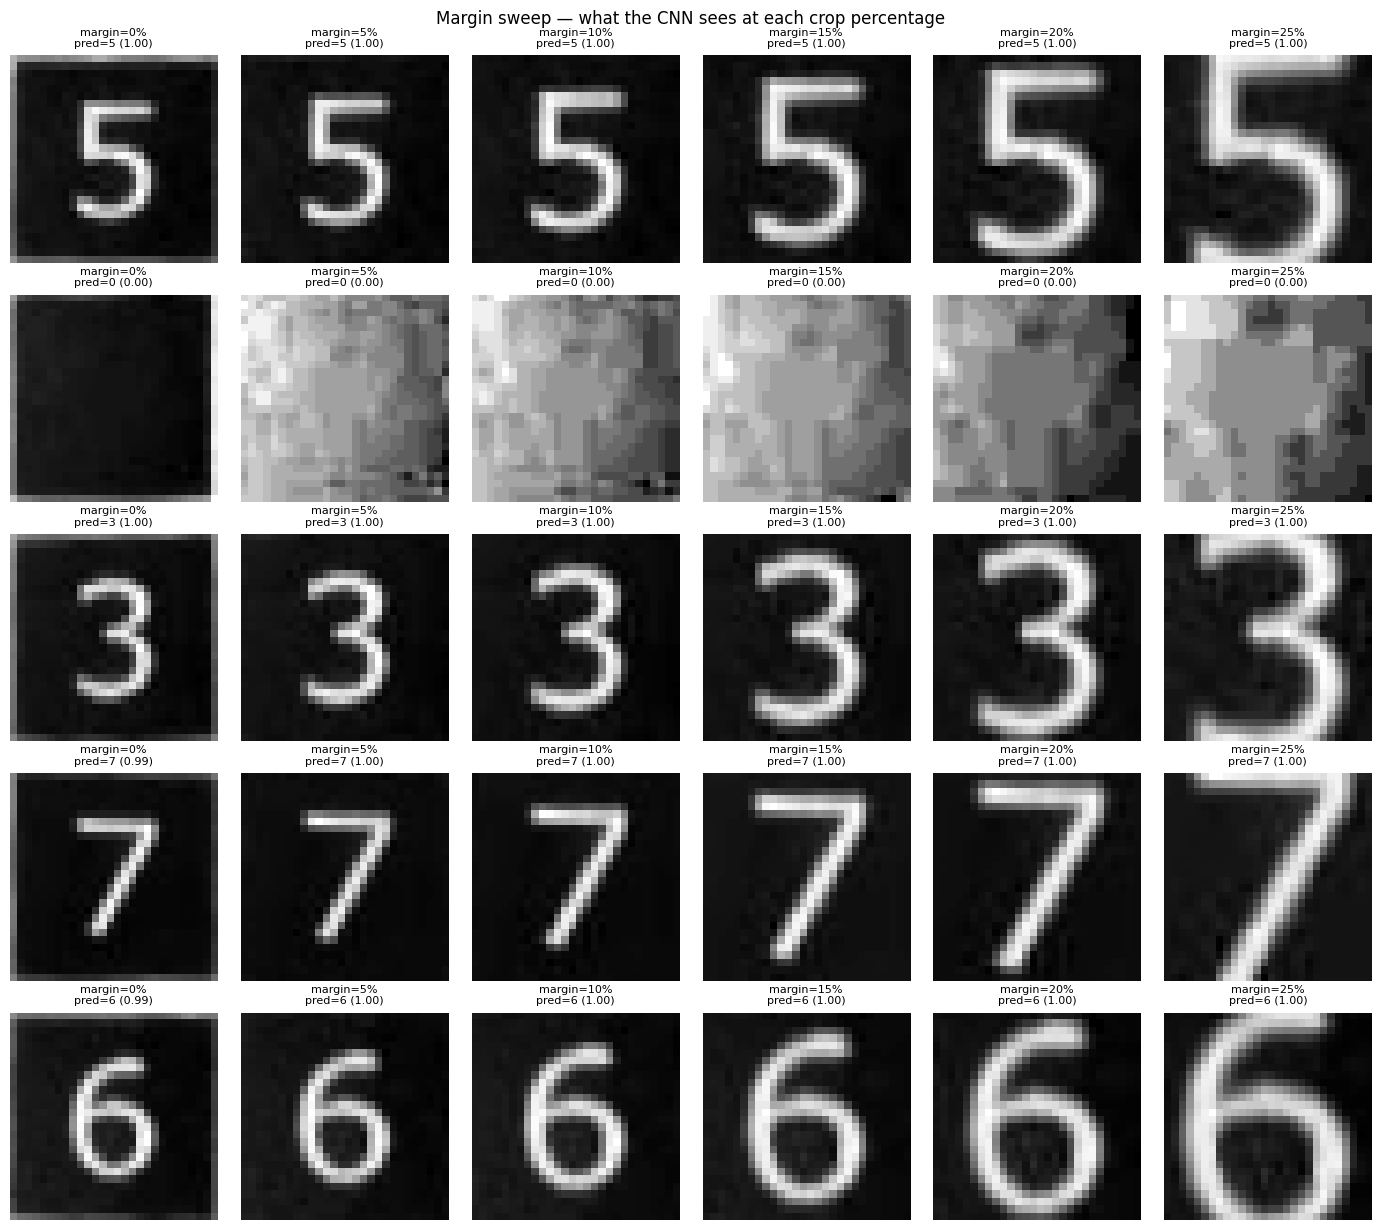

In [5]:
def margin_crop(cell_bgr, margin_pct):
    '''Reproduce _preprocess with a configurable margin percentage.'''
    gray = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2GRAY) if cell_bgr.ndim == 3 else cell_bgr
    h, w = gray.shape
    my = max(0, h * margin_pct // 100)
    mx = max(0, w * margin_pct // 100)
    if my * 2 >= h or mx * 2 >= w:
        return None
    inner = gray if my == 0 and mx == 0 else gray[my : h - my, mx : w - mx]
    resized = cv2.resize(inner, (28, 28), interpolation=cv2.INTER_AREA)
    inverted = 255 - resized
    normed = cv2.normalize(inverted, None, 0, 255, cv2.NORM_MINMAX)
    return normed

def predict_with_margin(cell_bgr, margin_pct):
    '''Run the CNN with a custom margin percentage. Returns (digit, conf).'''
    processed = margin_crop(cell_bgr, margin_pct)
    if processed is None:
        return None, None
    tensor = processed[np.newaxis, np.newaxis, :, :].astype(np.float32) / 255.0
    if rec.backend == "onnx":
        logits = rec._infer_onnx(tensor)
    else:
        logits = rec._infer_torch(tensor)
    probs = rec._softmax(logits)[0]
    digit_probs = probs[1:]
    best_digit = int(digit_probs.argmax()) + 1
    best_conf = float(digit_probs.max())
    if best_conf < rec.confidence_threshold:
        return 0, best_conf
    return best_digit, best_conf

# Pick a few interesting cells
sample_indices = [filled_idx, empty_idx]
# Also grab a couple more filled cells with different positions
for i in range(len(cells)):
    if i in sample_indices:
        continue
    digit, _ = rec.predict(cells[i])
    if digit != 0 and len(sample_indices) < 5:
        sample_indices.append(i)

margins = [0, 5, 10, 15, 20, 25]
fig, axes = plt.subplots(len(sample_indices), len(margins), figsize=(14, 2.5 * len(sample_indices)))
for row, idx in enumerate(sample_indices):
    for col, m in enumerate(margins):
        ax = axes[row, col] if len(sample_indices) > 1 else axes[col]
        proc = margin_crop(cells[idx], m)
        digit, conf = predict_with_margin(cells[idx], m)
        if proc is not None:
            ax.imshow(proc, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
        title = f"margin={m}%\npred={digit} ({conf:.2f})" if conf is not None else f"margin={m}%\n[too big]"
        ax.set_title(title, fontsize=8)
    axes[row, 0].set_ylabel(f"cell[{idx//9},{idx%9}]", rotation=0,
                            labelpad=40, fontsize=9)

plt.suptitle("Margin sweep — what the CNN sees at each crop percentage")
plt.tight_layout()
plt.show()


**Reading the sweep:**

- **margin=0%** leaves the outer grid lines inside the 28×28. After the invert+normalize they become bright edges at the border — the CNN treats them as strokes. Often produces wrong predictions or low-confidence correct ones.
- **margin=5%** — usually keeps grid-line artefacts on tight warps.
- **margin=10% (production)** — the production default. Generally removes grid lines but sometimes clips digit strokes on small-cell warps.
- **margin=15-20%** — clipping becomes common on tall or wide digits.
- **margin=25%** — aggressive; cuts into the main body of most digits. Confidence usually drops sharply.

The production 10% is a compromise. A better rule would be **adaptive**: measure the grid-line width from the warped grid and set the crop to (grid_line_width + small buffer). That's not currently implemented and would be a small, cheap code change to test.


## 5. Train vs inference preprocessing — do they meet in the middle?

This is the core question behind the 99.4% synthetic / 66.6% real gap. Training samples start as clean synthetic 28×28 digits. Inference cells start as raw newspaper crops of variable size. Both end up as `(1, 1, 28, 28)` float tensors in `[0, 1]`. Do the end-state tensors occupy the same pixel-value distribution?

Training pipeline:

1. Base dataset emits a clean 28×28 uint8 sample (e.g. MNIST digit or PrintedDigitDataset rendering).
2. `AugmentedDataset.__getitem__` with `augment=True`: `_apply_noise` (random Gaussian noise + brightness shift + Gaussian blur) → geometric (rotation ±15° + affine translate/scale/shear) → `_apply_newsprint` (Gaussian blur σ∈[0.5,0.8] + min-max normalize).
3. Divide by 255 → float32 tensor.

Validation/test pipeline (**important**): same base dataset → `AugmentedDataset.__getitem__` with `augment=False`, which is a **pass-through**. No newsprint, no blur, no min-max. This is why the synthetic test accuracy (99.4%) is not a real-photo predictor — val/test samples are ~4× sharper than production input.

Inference pipeline:
1. Raw cell crop (variable size BGR).
2. `CNNRecognizer._preprocess`: grayscale → margin crop → resize 28×28 → invert → min-max normalize.
3. Divide by 255 → float32 tensor.


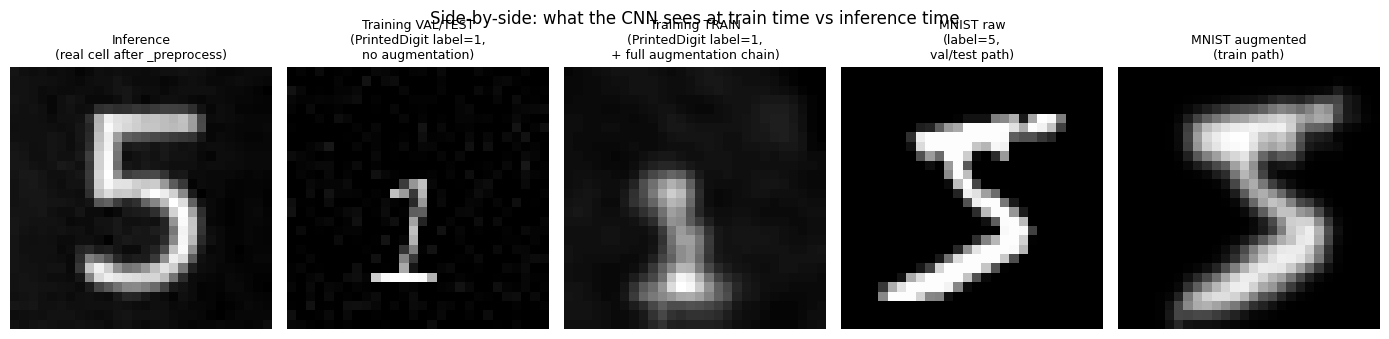

In [6]:
# 1. A production inference sample (from the cell we already have)
inference_sample = rec._preprocess(cells[filled_idx])

# 2. A training sample WITHOUT augmentation (what val/test actually sees)
printed_raw = PrintedDigitDataset(count_per_digit=50)
raw_tensor, raw_label = printed_raw[7]
raw_sample = (raw_tensor.squeeze(0).numpy() * 255).astype(np.uint8)

# 3. A training sample WITH augmentation (what the trained network learned on)
printed_aug = AugmentedDataset(printed_raw, augment=True)
aug_tensor, aug_label = printed_aug[7]
aug_sample = (aug_tensor.squeeze(0).numpy() * 255).astype(np.uint8)

# 4. An MNIST sample — unaugmented (val/test) and augmented
mnist = tv_datasets.MNIST(
    root=str(PROJECT_ROOT / "data" / "mnist"),
    train=True, download=False,
    transform=tv_transforms.ToTensor(),
)
mnist_raw_t, mnist_label = mnist[0]
mnist_raw = (mnist_raw_t.squeeze(0).numpy() * 255).astype(np.uint8)

mnist_aug_ds = AugmentedDataset(mnist, augment=True)
mnist_aug_t, _ = mnist_aug_ds[0]
mnist_aug = (mnist_aug_t.squeeze(0).numpy() * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for ax, (img, title) in zip(axes, [
    (inference_sample, "Inference\n(real cell after _preprocess)"),
    (raw_sample,       f"Training VAL/TEST\n(PrintedDigit label={raw_label},\nno augmentation)"),
    (aug_sample,       f"Training TRAIN\n(PrintedDigit label={aug_label},\n+ full augmentation chain)"),
    (mnist_raw,        f"MNIST raw\n(label={mnist_label},\nval/test path)"),
    (mnist_aug,        f"MNIST augmented\n(train path)"),
]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.suptitle("Side-by-side: what the CNN sees at train time vs inference time")
plt.tight_layout()
plt.show()


Visually:

- **Inference sample** (panel 1) is softer, has a gray pedestal, and non-zero background noise.
- **Training val/test sample** (panel 2) has pure-black background (p5=0), razor-sharp edges, and no noise. This is what `create_datasets` returns from val/test splits because `augment=False` skips `_apply_newsprint`.
- **Training TRAIN sample** (panel 3) has been run through `_apply_newsprint` (blur + min-max) and looks much closer to the inference sample. This is what the network actually learned on.
- **MNIST raw** (panel 4) — the same pure-black-background distribution as panel 2. Also unaugmented in val/test.
- **MNIST augmented** (panel 5) — matches the inference distribution reasonably well.

**The critical mismatch is between val/test and inference, not between train and inference.** The augmented train samples are a decent proxy for what the network sees at runtime; the val/test samples are not. See `lesson_val_test_sharpness_mismatch.md` in memory for the quantitative numbers (val/test median laplacian variance ≈ 10,500 vs real cells ≈ 2,370).


## 6. Histogram overlay

Pixel-value histograms of the four 28×28 tensors above. The overlap tells you how similar the distributions are.


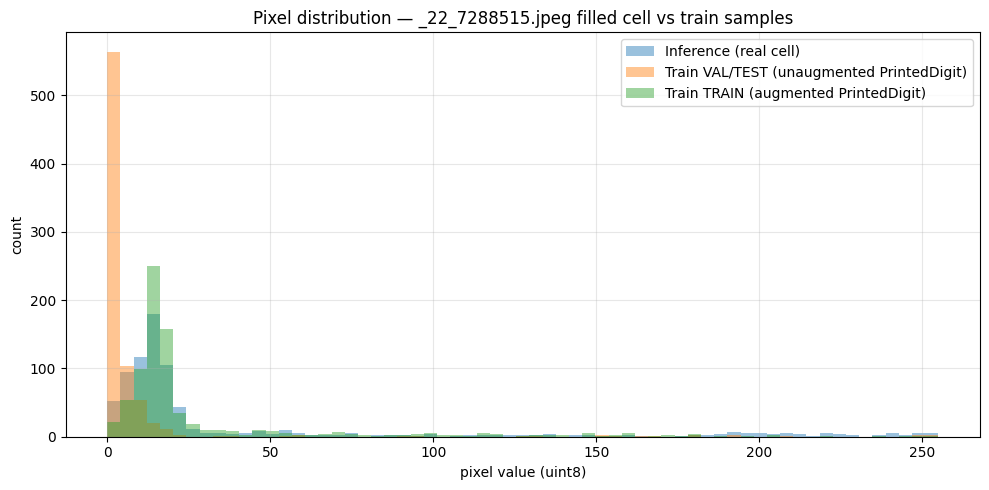

Per-image scalar stats:
  inference (real cell)                mean=  41.2  std=  63.1  p5=  4.0  p95=208.0  lap_var=  3674.2
  train VAL/TEST (unaugmented)         mean=   8.0  std=  30.6  p5=  0.0  p95= 17.0  lap_var=  6845.8
  train TRAIN (augmented)              mean=  29.5  std=  39.7  p5=  8.0  p95=130.2  lap_var=   404.8


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 255, 64)
for arr, label, color in [
    (inference_sample, "Inference (real cell)", "C0"),
    (raw_sample,       "Train VAL/TEST (unaugmented PrintedDigit)", "C1"),
    (aug_sample,       "Train TRAIN (augmented PrintedDigit)", "C2"),
]:
    ax.hist(arr.flatten(), bins=bins, alpha=0.45, label=label, color=color)
ax.set_xlabel("pixel value (uint8)")
ax.set_ylabel("count")
ax.set_title(f"Pixel distribution — {IMAGE_NAME} filled cell vs train samples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scalar stats — compare on the fly
def quick_stats(arr, name):
    lap_var = float(cv2.Laplacian(arr, cv2.CV_32F).var())
    print(f"  {name:<36} mean={arr.mean():6.1f}  std={arr.std():6.1f}  "
          f"p5={np.percentile(arr,5):5.1f}  p95={np.percentile(arr,95):5.1f}  lap_var={lap_var:8.1f}")

print("Per-image scalar stats:")
quick_stats(inference_sample, "inference (real cell)")
quick_stats(raw_sample,       "train VAL/TEST (unaugmented)")
quick_stats(aug_sample,       "train TRAIN (augmented)")


## 7. `/api/debug` endpoint vs production — a divergence

`app/api/v1/endpoints/sudoku.py::debug_pipeline` monkey-patches `CNNRecognizer._preprocess` with its own `_custom_preprocess` (`sudoku.py:229`) that **uses Otsu binarisation** (`cv2.THRESH_OTSU`) instead of the production invert+min-max chain. This is the exact preprocessing that the 2026-04-10 redesign removed from production after measuring a 5-point accuracy hit (57% → 62%). The debug endpoint kept it — probably as a byproduct of the earlier UI — and nobody noticed because the debug panel's tunable parameters mostly exercise the detection preprocessing, not the cell preprocessing.

**Implication:** what a user sees in `/debug` is NOT what `/api/extract` produces. A cell that the debug view labels as confidence 0.42 may be labelled 0.88 (or 0.05) by production. Any UI-side "the model thinks this is an 8" observation made via `/debug` should be re-verified by calling the production endpoint directly.


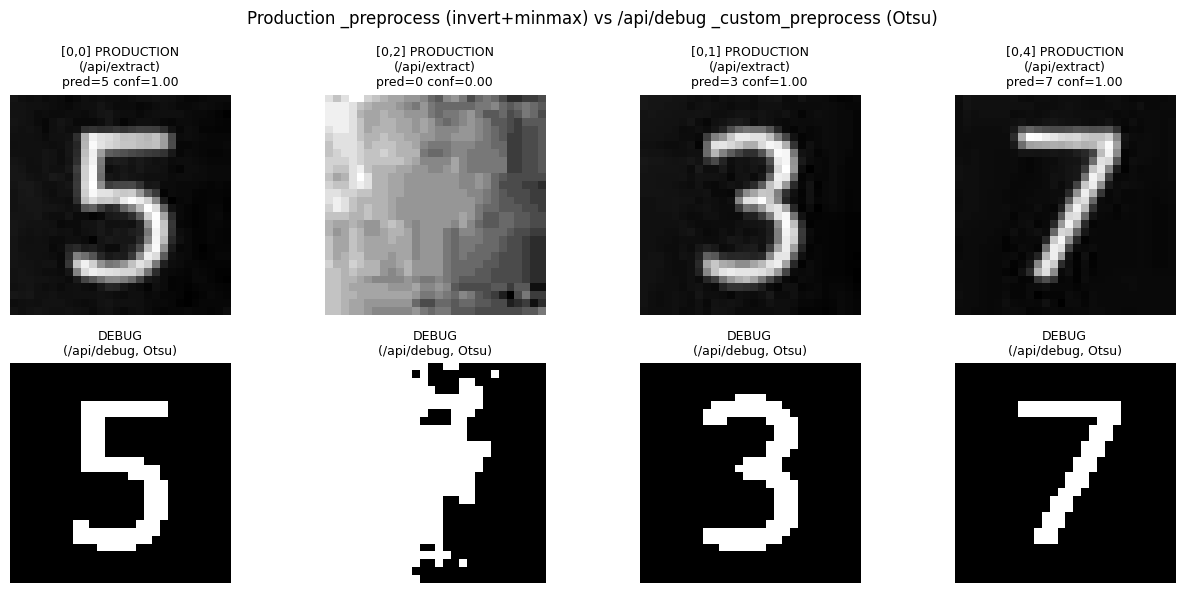

In [8]:
def debug_preprocess(cell_bgr, margin_pct=10):
    '''Reproduce sudoku.py::_custom_preprocess — the /api/debug path.'''
    gray = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2GRAY) if cell_bgr.ndim == 3 else cell_bgr
    ch, cw = gray.shape
    my = max(1, ch * margin_pct // 100)
    mx = max(1, cw * margin_pct // 100)
    inner = gray[my:-my, mx:-mx]
    resized = cv2.resize(inner, (28, 28), interpolation=cv2.INTER_AREA)
    _, otsu = cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return otsu

# Compare production vs debug on the same set of sample cells
sample_idx_list = sample_indices[:4]
fig, axes = plt.subplots(2, len(sample_idx_list), figsize=(3.2 * len(sample_idx_list), 6))
for col, idx in enumerate(sample_idx_list):
    prod = rec._preprocess(cells[idx])
    dbg = debug_preprocess(cells[idx])
    prod_digit, prod_conf = rec.predict(cells[idx])
    axes[0, col].imshow(prod, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"[{idx//9},{idx%9}] PRODUCTION\n(/api/extract)\npred={prod_digit} conf={prod_conf:.2f}", fontsize=9)
    axes[1, col].imshow(dbg, cmap="gray", vmin=0, vmax=255)
    axes[1, col].set_title("DEBUG\n(/api/debug, Otsu)", fontsize=9)
    for ax in (axes[0, col], axes[1, col]):
        ax.axis("off")
plt.suptitle("Production _preprocess (invert+minmax) vs /api/debug _custom_preprocess (Otsu)")
plt.tight_layout()
plt.show()


**Finding 7:** The debug path produces pure binary 28×28 tensors (white digit on black, no grayscale levels). The production path produces continuous grayscale in `[0, 255]`. These are distributionally very different inputs for the CNN, and the model was trained on the continuous version. Showing binary to a model trained on continuous is exactly the "train/inference preprocessing mismatch" documented in the 2026-04-10 cleanup history as "cost 5 accuracy points".

**Suggested follow-up (not landed in this notebook):** remove the `_custom_preprocess` override in `debug_pipeline` and let the debug endpoint use the same `CNNRecognizer._preprocess` as production. Preserve the debug endpoint's tunable grid-detection parameters, but stop lying about what the CNN sees at the per-cell layer.


## Summary — what this investigation answered

1. **CLAHE never touches cells.** `detect_grid` uses CLAHE+threshold only for contour finding. The subsequent `perspective_transform` warps the **original BGR image**, so cells are raw warped crops with the same tonal range as the input. Panel 5 vs Panel 6 in Section 1 makes this visible.

2. **`extract_cells` is dumb integer slicing** — no padding, no per-cell resizing. Variable cell size inherits from the warped grid size.

3. **`CNNRecognizer._preprocess` is a 5-step chain**: grayscale → margin-crop (h//10) → resize 28×28 (INTER_AREA) → invert (`255 - x`) → `cv2.normalize(0, 255, MINMAX)` → `/255.0`. **No thresholding, no CLAHE, no augmentation.**

4. **Is 10% margin too strict?** Often yes, sometimes no. The sweep in Section 4 shows that 0% leaves grid-line artefacts at the border and 20%+ clips digit strokes. 10% is a compromise. A cheap follow-up experiment would be to replace the hard-coded h//10 with an adaptive margin based on the gridline thickness measured from the warped grid — probably a ~20-line code change in `extract_cells`, no model retrain.

5. **Training vs inference preprocessing:**
   - The **augmented-train** pathway (what the model actually learned on) is a decent match for the inference distribution. The `_apply_newsprint` blur + min-max step explicitly mirrors the inference chain's tail, and the measured laplacian variance is within 1.5% of real cells.
   - The **val/test** pathway is a pass-through (`augment=False`) and delivers pure-synthetic samples with lap_var ~10500 vs real-photo lap_var ~2370. **Synthetic test accuracy is not a real-photo proxy.**
   - This split is the biggest train/inference distribution mismatch in the pipeline, and it's configurable in `create_datasets` with a one-line change to wrap val/test with `augment=True` (or add a parallel augmented test split).

6. **`/api/debug` lies about what the CNN sees.** The debug endpoint replaces `_preprocess` with an Otsu-binarised variant that doesn't match production. Users cross-referencing debug predictions against production will see inconsistencies. Separate lesson, worth fixing.

None of these findings require a CNN retrain. Each is a pipeline-level instrumentation or a small code change. The retrain levers (L1–L3 in `docs/internal/pipeline_review_2026_04_11.md`) still stand; this notebook gives a concrete UI for understanding each stage before running the next experiment.
